In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler

In [17]:
local_dataset = pd.read_csv("data/local/cebu.csv")
local_dataset.head()

,Patient,Age,Height (cm),Weight (kg),Body Mass Index (BMI),Blood Pressure,Menstrual Irregularities,Symptoms,Ultrasound Findings,Gravida
0,P1,34,1.57,64.0,25.9645,120/80,Irregular,"irregular masses, weight gain, hirsutism",PCO,G0P0
1,P2,22,1.53,52.0,22.2137,120/80,Irregular,"irregular masses, acne, weight gain",PCO,G0P0
2,P3,19,1.55,55.0,22.8928,110/70,Regular,"irregular masses, acne",PCO,G0P0
3,P4,24,1.55,55.0,22.8928,110/70,Irregular,"irregular masses, acne, weight gain",PCO,G0P0
4,P5,25,1.59,50.0,19.7777,110/71,Regular,irregular masses,PCO,G0P0


In [18]:
from adapter import Dataset1Adapter, LocalDatasetAdapter

In [19]:
adapter = LocalDatasetAdapter(local_dataset)
preprocessed_local_dataset = adapter.convert()

/Users/nickanthonymiras/Programming/projects/pcos-analysis/adapter.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_dataframe[features.infertility] = filtered_dataframe[features.infertility].apply(lambda x: 1 if x == 'G1P0' or x == 'G3P2' else 0)
/Users/nickanthonymiras/Programming/projects/pcos-analysis/adapter.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_dataframe[features.menstrual_irregularity] = filtered_dataframe[features.menstrual_irregularity].apply(lambda x: 1 if x == 

[Text(0, 0, 'No PCOS'), Text(1, 0, 'PCOS')]

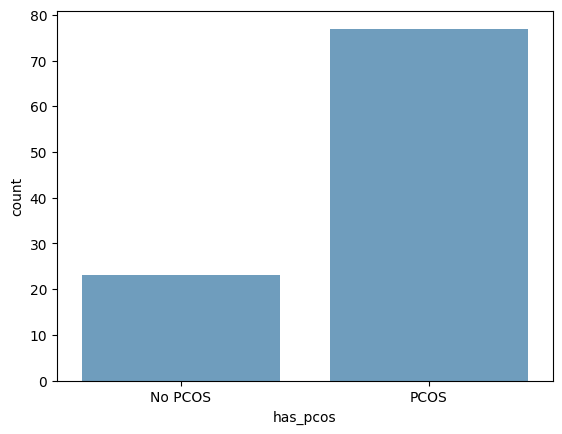

In [20]:
# plot dataset distribution for target variable of 1 and 0
ax = sns.countplot(data=preprocessed_local_dataset, x='has_pcos', alpha=0.7)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No PCOS', 'PCOS'])

In [21]:
# MinMaxScaler
preprocessed_local_dataset['bmi'] = MinMaxScaler().fit_transform(preprocessed_local_dataset[['bmi']])
preprocessed_local_dataset['age'] = MinMaxScaler().fit_transform(preprocessed_local_dataset[['age']])

In [22]:
# Define features and target variable
X = preprocessed_local_dataset.drop(columns=['has_pcos'])
y = preprocessed_local_dataset['has_pcos']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

In [23]:
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import accuracy_score

In [24]:
def objective(trial):
    C = trial.suggest_float('C', 1e-3, 100.0, log=True)
    max_iter = trial.suggest_int('max_iter', 100, 1000)

    logreg = LogisticRegression(
        C=C,
        max_iter=max_iter,
        solver='liblinear',
        random_state=42
    )
    logreg.fit(X_train, y_train)
    y_pred_val = logreg.predict(X_test)
    return accuracy_score(y_test, y_pred_val)

In [25]:

# Apply Tree-structured Parzen Estimator (TPE) Bayesian Optimization
sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50)

print("Best Parameters found via Parzen Tree (TPE):", study.best_trial.params)

[I 2026-03-26 19:16:05,364] A new study created in memory with name: no-name-f80ae85b-ea5a-4c75-ad08-8c85092bb37e
[I 2026-03-26 19:16:05,366] Trial 0 finished with value: 0.8333333333333334 and parameters: {'C': 0.07459343285726547, 'max_iter': 956}. Best is trial 0 with value: 0.8333333333333334.
[I 2026-03-26 19:16:05,368] Trial 1 finished with value: 0.8 and parameters: {'C': 4.570563099801454, 'max_iter': 639}. Best is trial 0 with value: 0.8333333333333334.
[I 2026-03-26 19:16:05,370] Trial 2 finished with value: 0.8333333333333334 and parameters: {'C': 0.006026889128682512, 'max_iter': 240}. Best is trial 0 with value: 0.8333333333333334.
[I 2026-03-26 19:16:05,371] Trial 3 finished with value: 0.8333333333333334 and parameters: {'C': 0.0019517224641449498, 'max_iter': 880}. Best is trial 0 with value: 0.8333333333333334.
[I 2026-03-26 19:16:05,373] Trial 4 finished with value: 0.8333333333333334 and parameters: {'C': 1.0129197956845737, 'max_iter': 737}. Best is trial 0 with val

Best Parameters found via Parzen Tree (TPE): {'C': 2.2099310173483246, 'max_iter': 811}


In [26]:

# Train model with best parameters
logreg_classifier = LogisticRegression(**study.best_trial.params, solver='liblinear', random_state=42)
logreg_classifier.fit(X_train, y_train)

y_pred = logreg_classifier.predict(X_test)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[ 2  3]
 [ 0 25]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.89      1.00      0.94        25

    accuracy                           0.90        30
   macro avg       0.95      0.70      0.76        30
weighted avg       0.91      0.90      0.88        30



# Conclusion